In [2]:
using Piccolo

In [41]:
using LinearAlgebra
using Plots
using QuantumToolbox
using CairoMakie
using Random

Random.seed!(42)

TaskLocalRNG()

constructing SmoothPulseProblem [UnitaryTrajectory]
QuantumControlProblem
├─ UnitaryTrajectory  ·  ZeroOrderPulse  ·  BilinearIntegrator, DerivativeIntegrator, DerivativeIntegrator
│  
├─ System
│    dim=2   drives=2
│  
├─ Trajectory
│    N=100   T=10.000   Δt∈[0, Inf]
│    Ũ⃗    (8)  ±[1.0, 1.0, 1.0, … (8 total)]  ✓  state
│    Δt   (1)  [0.0, Inf]                     ✓  timestep
│    t    (1)                                 ·  state
│    u    (2)  ±[1.0, 1.0]                    ✓  control
│    du   (2)                                 ·  control
│    ddu  (2)  ±[1.0, 1.0]                    ✓  control
│  
├─ Goal
│    U_goal  (2×2)
│  
├─ Objective   total = 105  @ current x
│    KnotPointObjective           w=1             99.14
│    QuadraticRegularizer(:u)     w=1             1.023e-04
│    QuadraticRegularizer(:du)    w=1             0.01995
│    QuadraticRegularizer(:ddu)   w=1             5.875
│    NullObjective                w=1             0
│  
├─ Constraints   1/14 violat

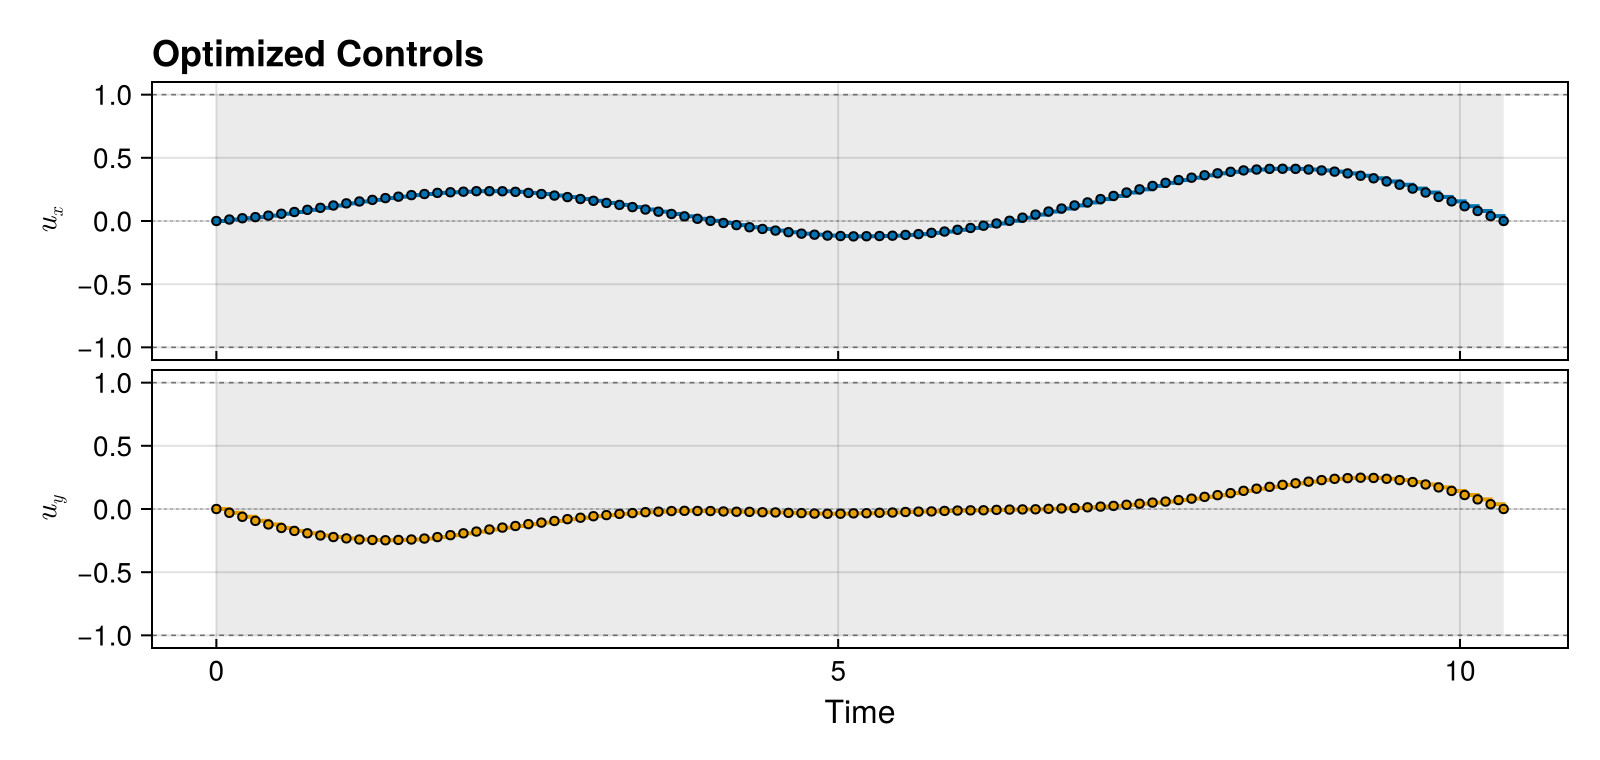

In [6]:
# The drift Hamiltonian: ω/2 σ_z (qubit frequency)
H_drift = 0.5 * PAULIS[:Z]
H_drives = [PAULIS[:X], PAULIS[:Y]]

drive_bounds = [1.0, 1.0]
sys = QuantumSystem(H_drift, H_drives, drive_bounds)

# Gate duration and discretization
T = 10.0   # Total time (in units where ω = 1)
N = 100    # Number of timesteps

times = collect(range(0, T, length = N))
initial_controls = 0.1 * randn(2, N)

# Create the pulse
pulse = ZeroOrderPulse(initial_controls, times)


# Our target: the X gate
U_goal = GATES[:X]

# Create the trajectory
qtraj = UnitaryTrajectory(sys, pulse, U_goal)

qcp = SmoothPulseProblem(
    qtraj,
    N;
    Q = 100.0,       # Fidelity weight (higher = prioritize fidelity)
    R = 1e-2,        # Regularization weight (higher = smoother controls)
    ddu_bound = 1.0,  # Limit on control acceleration
    piccolo_options = PiccoloOptions(timesteps_all_equal = true),
)


solve!(qcp; max_iter = 20, verbose = false, print_level = 1)


traj = get_trajectory(qcp)

# Check the final unitary
U_final = iso_vec_to_operator(traj[:Ũ⃗][:, end])
round.(U_final, digits = 3)


#THE GOAL IS TO APPLY THE X GATE TO ANY ARBITRARY STATE 
#THE WAY TO DO THIS IS BY CHANGING THE HAMILTONIAN AND APPLYING DIFFERENING AMOUNTS OF THE XGATE AND YGATE AT TIME INTERVALS
#SINCE THERE IS SOME Z DRIFT, IT IS NOT POSSIBLE TO ONLY APPLY THE X GATE BUT IT IS NEEDED TO DO X AND YGATE
#THE GRAPH REPRESENTS OVER 10 SECONDS HOW TO MOST OPTIMALLY APPLY X AND Y GATES SO THAT AT THE END OF THE TEN SECONDS THE INITIAL STATE IS CONVERTED TO X*INITIAL

plot_pulse(qcp; bounds = true, labels = ["u_x", "u_y"], title = "Optimized Controls")


constructing SmoothPulseProblem [KetTrajectory]
QuantumControlProblem
├─ KetTrajectory  ·  ZeroOrderPulse  ·  BilinearIntegrator, DerivativeIntegrator, DerivativeIntegrator
│  
├─ System
│    dim=2   drives=2
│  
├─ Trajectory
│    N=100   T=10.000   Δt∈[0, Inf]
│    ψ̃    (4)  ±[1.0, 1.0, 1.0, 1.0]  ✓  state
│    Δt   (1)  [0.0, Inf]             ✓  timestep
│    t    (1)                         ·  state
│    u    (2)  ±[1.0, 1.0]            ✓  control
│    du   (2)                         ·  control
│    ddu  (2)  ±[1.0, 1.0]            ✓  control
│  
├─ Goal
│    |ψ_init⟩ → |ψ_goal⟩  (dim=2)
│  
├─ Objective   total = 101.2  @ current x
│    KnotPointObjective           w=1             96.01
│    QuadraticRegularizer(:u)     w=1             9.980e-05
│    QuadraticRegularizer(:du)    w=1             0.01861
│    QuadraticRegularizer(:ddu)   w=1             5.186
│    NullObjective                w=1             0
│  
├─ Constraints   1/13 violated at x₀
│    [dyn]  BilinearIntegrator

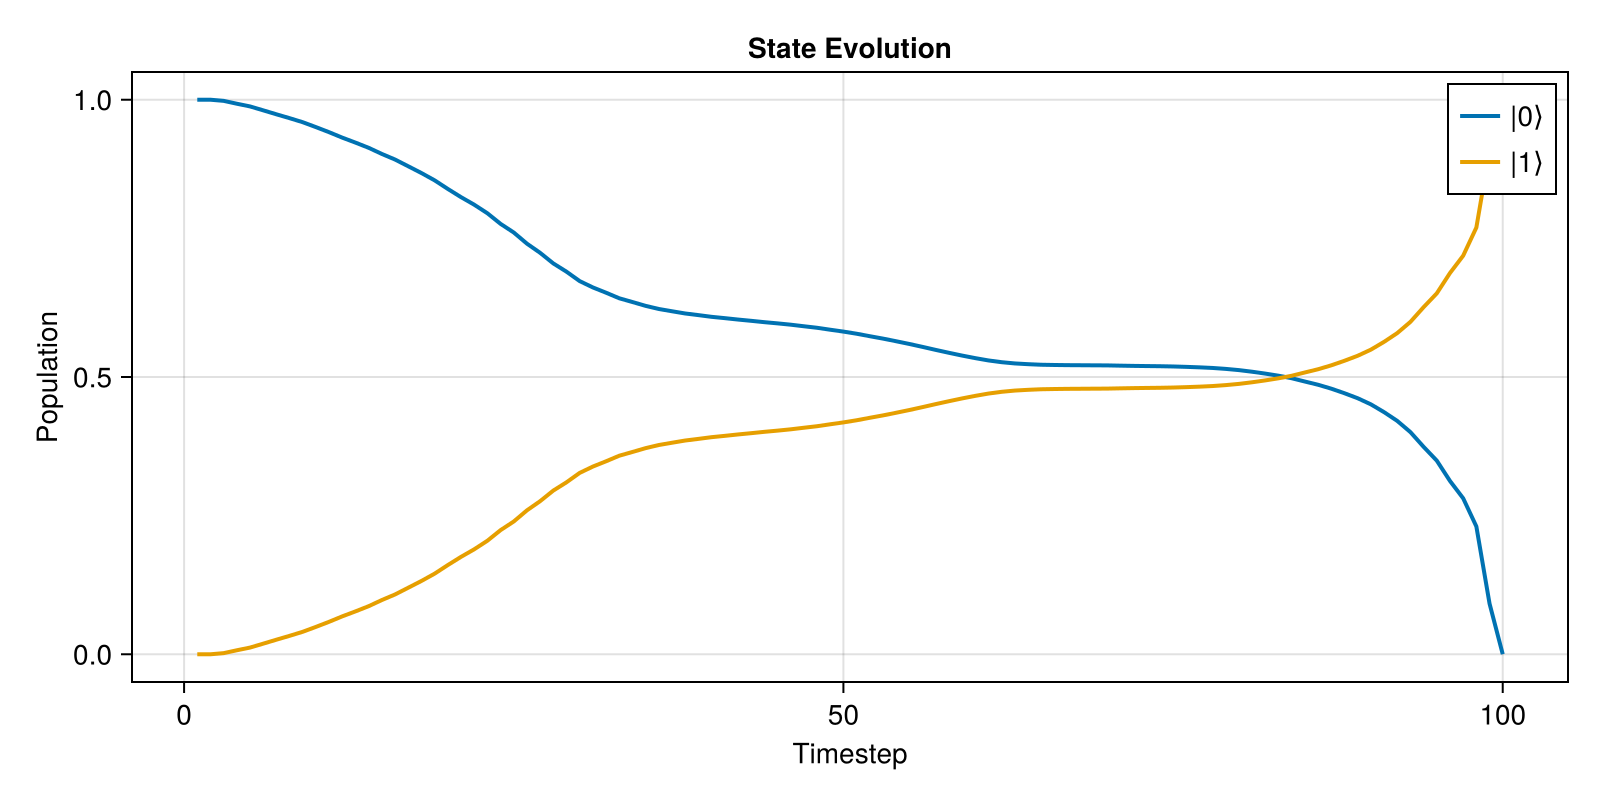

In [ ]:
# Create quantum system
H_drift = 0.5 * PAULIS[:Z]
H_drives = [PAULIS[:X], PAULIS[:Y]]
sys = QuantumSystem(H_drift, H_drives, [1.0, 1.0])

# Time parameters
T, N = 10.0, 100
times = collect(range(0, T, length = N))

# Initial pulse
pulse = ZeroOrderPulse(0.1 * randn(2, N), times)


# Initial state: |0⟩
ψ_init = ComplexF64[1.0, 0.0]

# Target state: |1⟩
ψ_goal = ComplexF64[0.0, 1.0]

# Create KetTrajectory
qtraj = KetTrajectory(sys, pulse, ψ_init, ψ_goal)

qcp = SmoothPulseProblem(qtraj, N; Q = 100.0, R = 1e-2)
solve!(qcp; max_iter = 20, verbose = false, print_level = 1)


traj = get_trajectory(qcp)

# Convert isomorphic states to physical states
n_steps = size(traj[:ψ̃], 2)
populations = zeros(2, n_steps)

for k = 1:n_steps
    ψ = iso_to_ket(traj[:ψ̃][:, k])
    populations[:, k] = abs2.(ψ)
end

# Plot
fig = Figure(size = (800, 400))

ax1 = Axis(fig[1, 1], xlabel = "Timestep", ylabel = "Population", title = "State Evolution")
lines!(ax1, 1:n_steps, populations[1, :], label = "|0⟩", linewidth = 2)
lines!(ax1, 1:n_steps, populations[2, :], label = "|1⟩", linewidth = 2)
axislegend(ax1, position = :rt)

fig


#THIS SYSTEM CONVERTS THE 0 STATE TO THE 1 STATE BY CONTROLLING X AND Y GATES
#This shows the probabilities to get the zero and the one state

    constructing SmoothPulseProblem for MultiKetTrajectory (2 states)...
QuantumControlProblem
├─ MultiKetTrajectory  ·  ZeroOrderPulse  ·  BilinearIntegrator, BilinearIntegrator, DerivativeIntegrator, DerivativeIntegrator
│  
├─ System
│    dim=2   drives=2
│  
├─ Trajectory
│    N=100   T=10.000   Δt∈[0, Inf]
│    ψ̃1   (4)  ±[1.0, 1.0, 1.0, 1.0]  ✓  state
│    ψ̃2   (4)  ±[1.0, 1.0, 1.0, 1.0]  ✓  state
│    Δt   (1)  [0.0, Inf]             ✓  timestep
│    t    (1)                         ·  state
│    u    (2)  ±[1.0, 1.0]            ✓  control
│    du   (2)                         ·  control
│    ddu  (2)  ±[1.0, 1.0]            ✓  control
│  
├─ Goal
│    2 state transfers  (dim=2)
│  
├─ Objective   total = 105.3  @ current x
│    KnotPointObjective           w=1             99.89
│    QuadraticRegularizer(:u)     w=1             1.021e-04
│    QuadraticRegularizer(:du)    w=1             0.0193
│    QuadraticRegularizer(:ddu)   w=1             5.426
│    NullObjective          

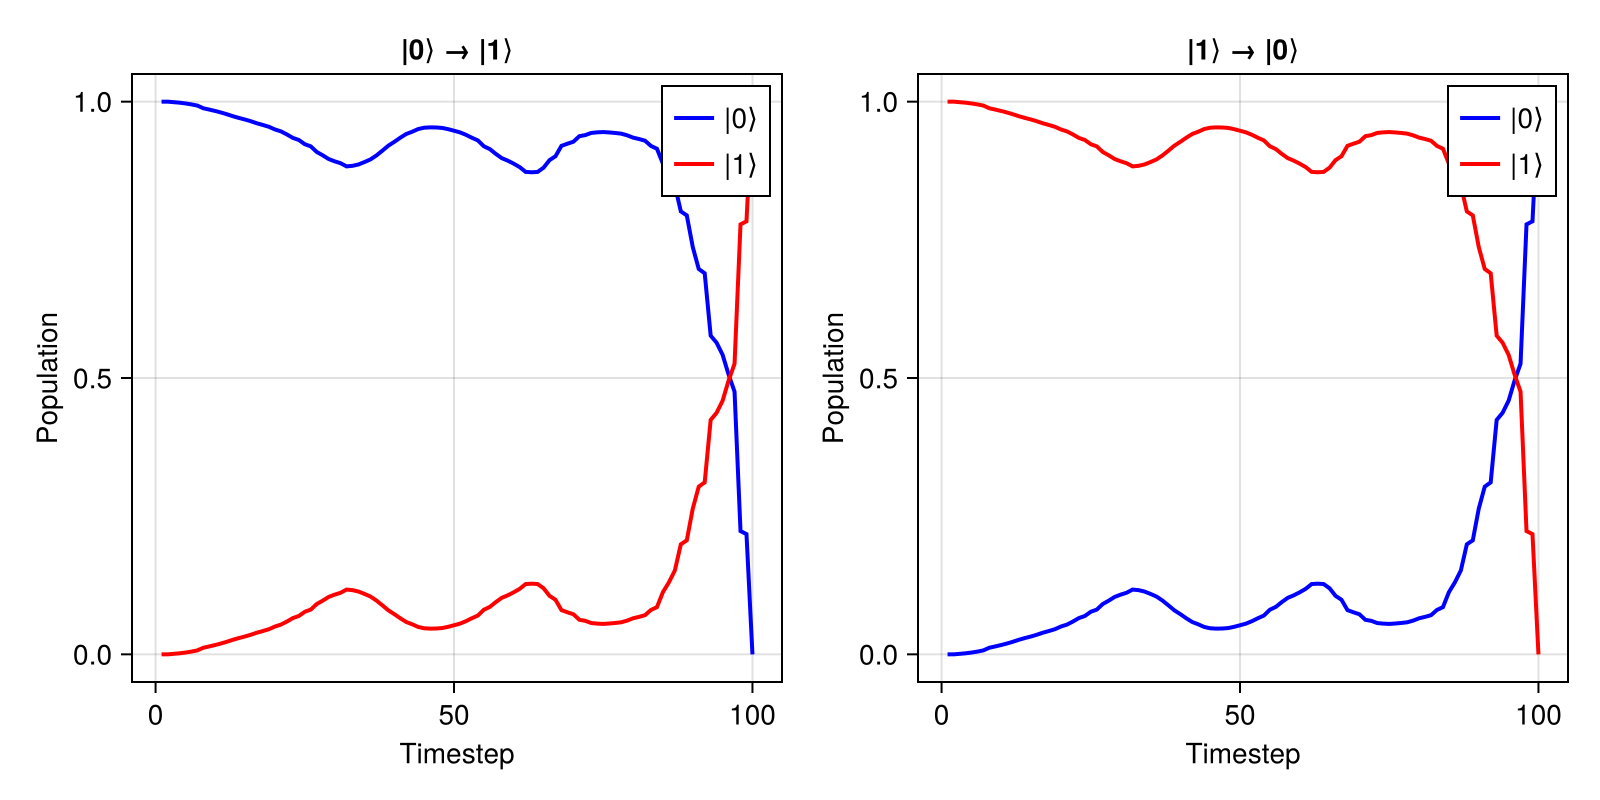

In [80]:
# Basis states
ψ0 = ComplexF64[1.0, 0.0]  # |0⟩
ψ1 = ComplexF64[0.0, 1.0]  # |1⟩

# Initial states and their targets
initial_states = [ψ0, ψ1]
goal_states = [ψ1, ψ0]  # X gate swaps them

# Create new pulse for this problem
pulse_multi = ZeroOrderPulse(0.1 * randn(2, N), times)

# Create MultiKetTrajectory
qtraj_multi = MultiKetTrajectory(sys, pulse_multi, initial_states, goal_states)

#THIS TRIES NOT JUST TO HAVE 0 TO 1 BUT THE WHOLE X GATE WITH 0 TO 1 AND 1 TO 0
#THIS IS DIFFERENT SINCE IT FLIPS 2 STATES AT ONCE

qcp_multi = SmoothPulseProblem(qtraj_multi, N; Q = 100.0, R = 1e-2)
solve!(
    qcp_multi;
    max_iter = 20,
    verbose = false,
    print_level = 1,
)



traj_multi = get_trajectory(qcp_multi)

# Extract populations for both initial states
# MultiKetTrajectory stores states as :ψ̃1, :ψ̃2, etc.
n_steps = size(traj_multi[:ψ̃1], 2)

pops1 = zeros(2, n_steps)  # Evolution from |0⟩
pops2 = zeros(2, n_steps)  # Evolution from |1⟩

for k = 1:n_steps
    ψ1_k = iso_to_ket(traj_multi[:ψ̃1][:, k])
    ψ2_k = iso_to_ket(traj_multi[:ψ̃2][:, k])
    pops1[:, k] = abs2.(ψ1_k)
    pops2[:, k] = abs2.(ψ2_k)
end

fig2 = Figure(size = (800, 400))

ax1 = Axis(fig2[1, 1], xlabel = "Timestep", ylabel = "Population", title = "|0⟩ → |1⟩")
lines!(ax1, 1:n_steps, pops1[1, :], label = "|0⟩", linewidth = 2, color = :blue)
lines!(ax1, 1:n_steps, pops1[2, :], label = "|1⟩", linewidth = 2, color = :red)
axislegend(ax1, position = :rt)

ax2 = Axis(fig2[1, 2], xlabel = "Timestep", ylabel = "Population", title = "|1⟩ → |0⟩")
lines!(ax2, 1:n_steps, pops2[1, :], label = "|0⟩", linewidth = 2, color = :blue)
lines!(ax2, 1:n_steps, pops2[2, :], label = "|1⟩", linewidth = 2, color = :red)
axislegend(ax2, position = :rt)

fig2

#This also shows the probabiliy to get the zero or one state but shows for each of the chaning system
#0 pop means 0% while 1 pop means 100%

In [1]:
using Piccolo
using SparseArrays
using Random;
Random.seed!(123);

using CairoMakie

T₀ = 10     # total time in ns
N = 50      # number of time steps
Δt = T₀ / N # time step
times = collect(range(0, T₀, length = N))

# define the system parameters
levels = 5
δ = 0.2

# add a bound to the controls
u_bound = [0.2, 0.2]
ddu_bound = 1.0

# create the system
sys = TransmonSystem(drive_bounds = u_bound, levels = levels, δ = δ)

# let's look at the drives of the system
get_drives(sys)[1] |> sparse

# define the target operator
op = EmbeddedOperator(:X, sys)

# show the full operator
op.operator |> sparse

# create a random initial pulse
initial_controls = 0.1 * randn(2, N)
pulse = ZeroOrderPulse(initial_controls, times)

# create a unitary trajectory with the embedded operator as goal
qtraj = UnitaryTrajectory(sys, pulse, op)

# create the optimization problem
qcp = SmoothPulseProblem(qtraj, N; ddu_bound = ddu_bound, Q = 100.0, R = 1e-2)

solve!(qcp; max_iter = 50)

constructing SmoothPulseProblem [UnitaryTrajectory]


┌ Warning: Trajectory has timestep variable :Δt but no bounds on it.
│ Adding default lower bound of 0 to prevent negative timesteps.
│ 
│ Recommended: Add explicit bounds when creating the trajectory:
│   NamedTrajectory(...; Δt_bounds=(min, max))
│ Example:
│   NamedTrajectory(qtraj, N; Δt_bounds=(1e-3, 0.5))
│ 
│ Or use timesteps_all_equal=true in problem options to fix timesteps.
└ @ DirectTrajOpt.Problems /Users/bordeim1/.julia/packages/DirectTrajOpt/VOKy2/src/problems.jl:66


QuantumControlProblem
├─ UnitaryTrajectory  ·  ZeroOrderPulse  ·  BilinearIntegrator, DerivativeIntegrator, DerivativeIntegrator
│  
├─ System
│    dim=5   drives=2
│  
├─ Trajectory
│    N=50   T=10.000   Δt∈[0, Inf]
│    Ũ⃗    (50)  ±[1.0, 1.0, 1.0, … (50 total)]  ✓  state
│    Δt   ( 1)  [0.0, Inf]                      ✓  timestep
│    t    ( 1)                                  ·  state
│    u    ( 2)  ±[0.2, 0.2]                     ✓  control
│    du   ( 2)                                  ·  control
│    ddu  ( 2)  ±[1.0, 1.0]                     ✓  control
│  
├─ Goal
│    EmbeddedOperator on [5], subspace dim 2
│  
├─ Objective   total = 61.77  @ current x
│    KnotPointObjective           w=1             61.06
│    QuadraticRegularizer(:u)     w=1             1.789e-04
│    QuadraticRegularizer(:du)    w=1             9.879e-03
│    QuadraticRegularizer(:ddu)   w=1             0.7016
│    NullObjective                w=1             0
│  
├─ Constraints   1/13 violated at x₀
│